### ==============================================================================
## Combined Lag Analysis - FaSt-SWOT & BioSWOT
### Authors: Elisabet Verger-Miralles (everger@imedea.uib-csic.es)
### Combined Processing and Visualization
#
**DESCRIPTION**:
 This script combines the lag analysis from both FaSt-SWOT and BioSWOT experiments.
 It generates a 2x2 subplot figure showing:
 (a) FaSt-SWOT Leg1 (Normal regime)
 (b) FaSt-SWOT Leg1 (Anomaly regime)
 (c) FaSt-SWOT Leg2
 (d) BioSWOT (Standard regime)
#
### ==============================================================================


In [1]:
import xarray as xr
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.stats import linregress
import warnings

warnings.filterwarnings("ignore")

c:\Users\ASUS\anaconda3\envs\env_elisabet\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\ASUS\anaconda3\envs\env_elisabet\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
# ==========================================
# 1. CONFIGURATION
# ==========================================
BASE_ROOT_FASTSWOT = Path(r"C:\Users\ASUS\Desktop\MVP\MVP_paper_data_figures_publish\MVP_fastswot_nc_final_processing")
BASE_ROOT_BIOSWOT = Path(r"C:\Users\ASUS\Desktop\MVP\MVP_paper_data_figures_publish\MVP_bioswot_nc_final_processing")

LEGS_FASTSWOT = {
    "FaSt_Leg1": BASE_ROOT_FASTSWOT / "Data" / "Leg1" / "processed_step1_highres_qc",
    "FaSt_Leg2": BASE_ROOT_FASTSWOT / "Data" / "Leg2" / "processed_step1_highres_qc",
}

PATH_BIOSWOT = BASE_ROOT_BIOSWOT / "Data" / "processed_step1_highres_qc"

# Parameters
FS_HZ = 25
WINDOW_SIZE = 125
WINDOW_SECONDS = WINDOW_SIZE / FS_HZ


STEP_SIZE = WINDOW_SIZE // 2
MAX_LAG_SEARCH_FASTSWOT = 10
MAX_LAG_SEARCH_BIOSWOT = 2
MIN_CORR = 0.8
MIN_GRADIENT = 1e-4

SPLIT_THRESHOLD_LEG1 = 1.5
DEPTH_MIN_CHECK = 10.0
DEPTH_MAX_CHECK = 80.0

# Output
OUT_DIR = Path(r"C:\Users\ASUS\Desktop\mvp_paper\codes_paper_publish\COMBINED_LAG_FIGURES")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"✅ Configuration loaded. Output dir: {OUT_DIR}")
print(f"✅ Window: {WINDOW_SIZE} scans ({WINDOW_SECONDS:.1f} s at {FS_HZ} Hz)")

✅ Configuration loaded. Output dir: C:\Users\ASUS\Desktop\mvp_paper\codes_paper_publish\COMBINED_LAG_FIGURES
✅ Window: 125 scans (5.0 s at 25 Hz)


In [3]:
# ==========================================
# 2. FUNCTIONS
# ==========================================

def calculate_fractional_lag(t_seg, c_seg, max_lag=10):
    """Calculates fractional lag between two segments using cross-correlation and parabolic fit."""
    t_seg = t_seg - np.mean(t_seg)
    c_seg = c_seg - np.mean(c_seg)
    lags = np.arange(-max_lag, max_lag + 1)
    corrs = []
    
    for lag in lags:
        if lag < 0: 
            c_shift = c_seg[-lag:]
            t_cut = t_seg[:len(c_shift)]
        elif lag > 0: 
            c_shift = c_seg[:-lag]
            t_cut = t_seg[lag:]
        else: 
            c_shift = c_seg
            t_cut = t_seg
            
        if len(c_shift) > 10:
            norm = np.std(t_cut) * np.std(c_shift)
            val = np.mean(t_cut * c_shift) / norm if norm > 1e-9 else 0
        else: 
            val = 0
            
        corrs.append(val)
        
    corrs = np.array(corrs)
    idx_max = np.argmax(corrs)
    
    if 0 < idx_max < len(corrs) - 1:
        y = corrs[idx_max-1 : idx_max+2]
        x = lags[idx_max-1 : idx_max+2]
        try:
            coeffs = np.polyfit(x, y, 2)
            if coeffs[0] < 0: 
                return -coeffs[1] / (2 * coeffs[0]), corrs[idx_max]
        except: 
            pass
            
    return float(lags[idx_max]), corrs[idx_max]

def remove_outliers_iqr(df, col='lag_scans'):
    """Removes statistical outliers using IQR method."""
    if len(df) < 3: 
        return df
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    return df[(df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR)]

print("✅ Functions defined")

✅ Functions defined


In [4]:
# ==========================================
# 3. PROCESS FaSt-SWOT DATA
# ==========================================
print("\n📊 Processing FaSt-SWOT data...")
results_fastswot = []
all_files_leg1 = []

for leg_name, path in LEGS_FASTSWOT.items():
    if not path.exists(): 
        print(f"⚠️ Path not found: {path}")
        continue
        
    files = sorted(list(path.glob("*.nc")))
    print(f"  > {leg_name}: Processing {len(files)} files")
    
    for f in files:
        if "Leg1" in leg_name: 
            all_files_leg1.append(f.name)
            
        try:
            with xr.open_dataset(f) as ds:
                p = ds.pressure.values
                t = ds.t1.values
                c = ds.c1.values
                w = ds.w_descent.values
                
                mask = (p > 5) & (p < 250)
                p, t, c, w = p[mask], t[mask], c[mask], w[mask]
                
                for i in range(0, len(p) - WINDOW_SIZE, STEP_SIZE):
                    t_s = t[i:i+WINDOW_SIZE]
                    c_s = c[i:i+WINDOW_SIZE]
                    w_s = w[i:i+WINDOW_SIZE]
                    p_s = p[i:i+WINDOW_SIZE]
                    
                    if np.nanmean(w_s) < 0.2: 
                        continue
                    if np.std(np.diff(t_s)) < MIN_GRADIENT: 
                        continue
                    
                    lag, corr = calculate_fractional_lag(np.diff(t_s), np.diff(c_s), max_lag=MAX_LAG_SEARCH_FASTSWOT)
                    if corr >= MIN_CORR and abs(lag) < MAX_LAG_SEARCH_FASTSWOT:
                        results_fastswot.append({
                            'dataset': leg_name, 
                            'file': f.name, 
                            'pressure_mean': np.mean(p_s), 
                            'w_mean': np.mean(w_s), 
                            'lag_scans': lag
                        })
        except Exception as e:
            pass

df_fastswot = pd.DataFrame(results_fastswot)
print(f"  ✅ Extracted {len(df_fastswot)} segments from FaSt-SWOT")


📊 Processing FaSt-SWOT data...
  > FaSt_Leg1: Processing 591 files
  > FaSt_Leg2: Processing 297 files
  ✅ Extracted 9361 segments from FaSt-SWOT


In [5]:
# ==========================================
# 4. CLASSIFY LEG 1 INTO NORMAL/ANOMALY
# ==========================================
print("\n🔍 Classifying FaSt-SWOT Leg1...")
df_leg1 = df_fastswot[df_fastswot['dataset'] == 'FaSt_Leg1']
df_check = df_leg1[(df_leg1['pressure_mean'] >= DEPTH_MIN_CHECK) & (df_leg1['pressure_mean'] <= DEPTH_MAX_CHECK)]

file_medians = df_check.groupby('file')['lag_scans'].median()
files_anomaly = file_medians[file_medians > SPLIT_THRESHOLD_LEG1].index.tolist()
files_normal = file_medians[file_medians <= SPLIT_THRESHOLD_LEG1].index.tolist()

# Files without enough data are marked as anomaly
classified = set(files_anomaly + files_normal)
for f in all_files_leg1:
    if f not in classified:
        files_anomaly.append(f)

print(f"  > Normal profiles: {len(files_normal)} files")
print(f"  > Anomaly profiles: {len(files_anomaly)} files")

# Assign plot group
df_fastswot['plot_group'] = np.nan
df_fastswot.loc[(df_fastswot['dataset'] == 'FaSt_Leg1') & (df_fastswot['file'].isin(files_normal)), 'plot_group'] = 'FaSt-SWOT Leg1 Regime 1'
df_fastswot.loc[(df_fastswot['dataset'] == 'FaSt_Leg1') & (df_fastswot['file'].isin(files_anomaly)), 'plot_group'] = 'FaSt-SWOT Leg1 Regime 2'
df_fastswot.loc[(df_fastswot['dataset'] == 'FaSt_Leg2'), 'plot_group'] = 'FaSt-SWOT Leg2'

print("✅ Classifications done")


🔍 Classifying FaSt-SWOT Leg1...
  > Normal profiles: 460 files
  > Anomaly profiles: 131 files
✅ Classifications done


In [6]:
# ==========================================
# 5. PROCESS BioSWOT DATA
# ==========================================
print("\n📊 Processing BioSWOT data...")
results_bioswot = []

if PATH_BIOSWOT.exists():
    files = sorted(list(PATH_BIOSWOT.glob("*.nc")))
    print(f"  > Processing {len(files)} files")
    
    for f in files:
        try:
            with xr.open_dataset(f) as ds:
                if 't1' not in ds:
                    continue
                    
                p = ds['pressure'].values
                t = ds['t1'].values
                c = ds['c1'].values
                w = ds['w_descent'].values
                
                for i in range(0, len(p) - WINDOW_SIZE, WINDOW_SIZE):
                    t_seg = t[i : i+WINDOW_SIZE]
                    if np.isnan(t_seg).any(): 
                        continue
                    if np.std(np.diff(t_seg)) < MIN_GRADIENT: 
                        continue
                    
                    w_seg = w[i : i+WINDOW_SIZE]
                    w_mean = np.mean(w_seg)
                    if w_mean < 0.2: 
                        continue

                    c_seg = c[i : i+WINDOW_SIZE]
                    p_seg = p[i : i+WINDOW_SIZE]
                    p_mean = np.mean(p_seg)
                    
                    dt = np.diff(t_seg)
                    dc = np.diff(c_seg)
                    lag, corr = calculate_fractional_lag(dt, dc, max_lag=MAX_LAG_SEARCH_BIOSWOT)
                    
                    if corr >= MIN_CORR and abs(lag) < MAX_LAG_SEARCH_BIOSWOT:
                        results_bioswot.append({
                            'dataset': 'BioSWOT',
                            'file': f.name,
                            'pressure_mean': p_mean,
                            'w_mean': w_mean,
                            'lag_scans': lag,
                            'correlation': corr
                        })
        except Exception as e:
            pass
else:
    print(f"⚠️ BioSWOT path not found: {PATH_BIOSWOT}")

df_bioswot = pd.DataFrame(results_bioswot)
df_bioswot['plot_group'] = 'BioSWOT-Med'

print(f"  ✅ Extracted {len(df_bioswot)} segments from BioSWOT")


📊 Processing BioSWOT data...
  > Processing 629 files
  ✅ Extracted 1537 segments from BioSWOT



📈 Creating 2x2 combined figure...
✅ Figure saved to: C:\Users\ASUS\Desktop\mvp_paper\codes_paper_publish\COMBINED_LAG_FIGURES\combined_lag_analysis_2x2.png
✅ Models saved to: C:\Users\ASUS\Desktop\mvp_paper\codes_paper_publish\COMBINED_LAG_FIGURES\combined_lag_models.csv

MODEL RESULTS (R² calculated vs binned means):
                 regime     slope  intercept  n_segments  n_bins  r_squared
FaSt-SWOT Leg1 Regime 1 -0.041398   0.187398        3935       9   0.653742
FaSt-SWOT Leg1 Regime 2 -0.083398   4.121808         592       9   0.952346
         FaSt-SWOT Leg2 -0.029168   0.122144        4178       8   0.897741
            BioSWOT-Med  0.018004   0.072264        1496       9   0.586028


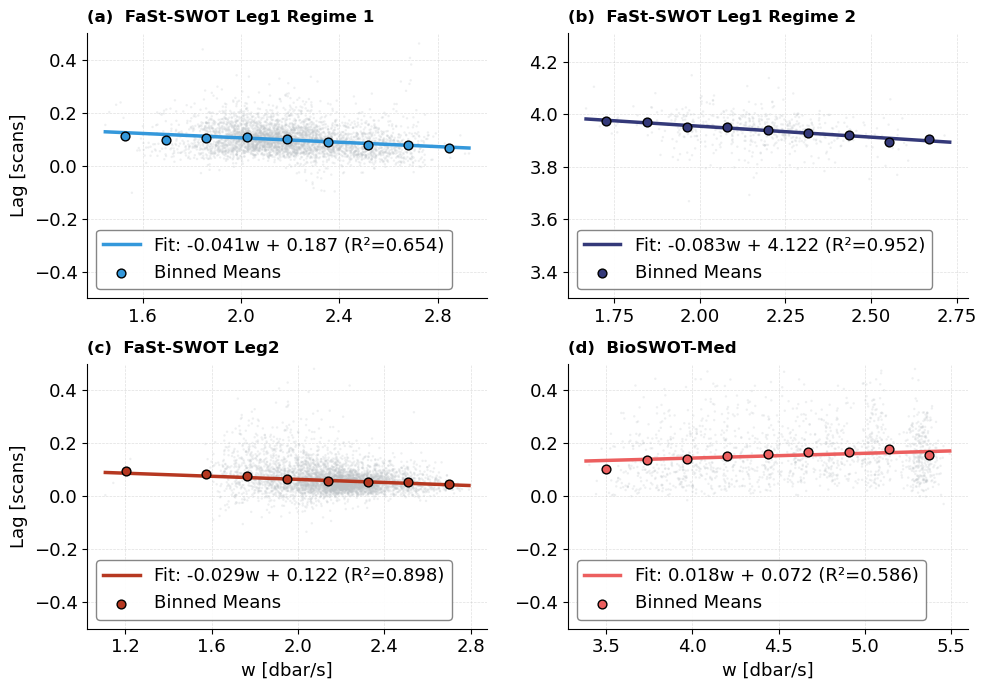

In [7]:
# ==========================================
# 6. PLOT 2x2 FIGURE
# ==========================================
print("\n📈 Creating 2x2 combined figure...")

# Set figsize para papel profesional
fig, axs = plt.subplots(2, 2, figsize=(10, 7), constrained_layout=True)

# Flatten axes for easier iteration
axs_flat = axs.flatten()

# Define plot configurations con colores armónicos (paleta científica)
plot_configs = [
    ('FaSt-SWOT Leg1 Regime 1', '#3498db', '(a)', 0),           # Azul claro-gris
    ('FaSt-SWOT Leg1 Regime 2', "#343979", '(b)', 1),   # Rojo suave
    ('FaSt-SWOT Leg2', "#b63821", '(c)', 2),           # Verde profesional
    ('BioSWOT-Med', "#ec5f5f", '(d)', 3),                  # Púrpura suave
]

model_results = []

for group_name, color, label, ax_idx in plot_configs:
    ax = axs_flat[ax_idx]
    
    # Select data based on group
    if 'BioSWOT-Med' in group_name:
        d_sub = df_bioswot[df_bioswot['plot_group'] == group_name]
    else:
        d_sub = df_fastswot[df_fastswot['plot_group'] == group_name]
    
    if d_sub.empty:
        ax.text(0.5, 0.5, f'No data for {group_name}', ha='center', va='center', 
                transform=ax.transAxes, fontsize=13, color='red')
        ax.set_title(f"{label} {group_name}", fontweight='bold', fontsize=12)
        continue
    
    # Scatter plot of all data with improved styling
    ax.scatter(d_sub['w_mean'], d_sub['lag_scans'], c='#bdc3c7', s=3, alpha=0.25, 
               edgecolors='none')
    
    # Remove outliers and fit line
    d_clean = remove_outliers_iqr(d_sub)
    
    if len(d_clean) > 5:
        slope, intercept, r_val, p_val, std_err = linregress(d_clean['w_mean'], d_clean['lag_scans'])
        
        # Calculate binned means and R² against the fit
        bins = np.linspace(d_clean['w_mean'].min(), d_clean['w_mean'].max(), 10)
        binned = d_clean.groupby(pd.cut(d_clean['w_mean'], bins))['lag_scans'].mean()
        bin_mids = np.array([b.mid for b in binned.dropna().index])
        bin_vals = binned.dropna().values
        
        # Calculate R² between binned means and fitted line
        y_pred_binned = slope * bin_mids + intercept
        ss_res = np.sum((bin_vals - y_pred_binned) ** 2)
        ss_tot = np.sum((bin_vals - np.mean(bin_vals)) ** 2)
        r2_binned = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0
        
        model_results.append({
            'regime': group_name, 
            'slope': slope, 
            'intercept': intercept,
            'n_segments': len(d_clean),
            'n_bins': len(bin_mids),
            'r_squared': r2_binned  # R² calculado contra binned means
        })
        
        x_vals = np.array([d_clean['w_mean'].min(), d_clean['w_mean'].max()])
        ax.plot(x_vals, slope*x_vals + intercept, color=color, lw=2.5, zorder=5,
               label=f"Fit: {slope:.3f}w + {intercept:.3f} (R²={r2_binned:.3f})")
        
        # Binned mean con mejor estilo
        ax.scatter(bin_mids, bin_vals, color=color, s=40, edgecolor='black', zorder=6,
                   label='Binned Means')
        
    # Formatting mejorado para paper
    ax.set_title(f"{label}  {group_name}", fontweight='bold', fontsize=12, pad=8, loc='left')
    ax.set_xlabel('w [dbar/s]', fontsize=13, fontweight='normal')
    ax.set_ylabel('Lag [scans]', fontsize=13, fontweight='normal')

    # tick labels mas grandes
    ax.tick_params(axis='both', which='major', labelsize=13)
    # reducir ticks para legibilidad
    ax.xaxis.set_major_locator(plt.MaxNLocator(5))

    # quitar x labels para filas superiores
    if ax_idx < 2:
        ax.set_xlabel('')
    # quitar y labels para columnas derechas
    if ax_idx % 2 == 1:
        ax.set_ylabel('')

    
    # Set y limits based on regime
    if 'Regime 2' in group_name:
        ax.set_ylim(3.3, 4.31)
    else:
        ax.set_ylim(-0.5, 0.5)
    
    # Mejorar grilla
    ax.grid(True, alpha=0.4, linestyle='--', linewidth=0.5)
    ax.set_axisbelow(True)
    
    # Mejorar leyenda
    ax.legend(fontsize=13, loc='lower left', framealpha=0.95, edgecolor='gray')
    
    # Spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()


# Save figure SIN suptitle
output_fig = OUT_DIR / "combined_lag_analysis_2x2.png"
plt.savefig(output_fig, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
print(f"✅ Figure saved to: {output_fig}")

# Save models
df_models = pd.DataFrame(model_results)
output_models = OUT_DIR / "combined_lag_models.csv"
df_models.to_csv(output_models, index=False)
print(f"✅ Models saved to: {output_models}")
print("\n" + "="*60)
print("MODEL RESULTS (R² calculated vs binned means):")
print("="*60)
print(df_models.to_string(index=False))
print("="*60)


plt.show()